
# EE 467 Final Project  
## Botnet Detection Using Machine Learning  

**Team Members:** Ethan Le, Dhruv Naik  

This notebook implements:
- Binary botnet detection (Botnet vs Non-Botnet)
- Scenario-based train/test splitting
- Leakage control
- Logistic Regression baseline
- Random Forest + XGBoost
- Autoencoder anomaly baseline
- Recall @ Fixed FPR evaluation



## 1. Imports and Configuration

This section loads required libraries and sets random seeds for reproducibility.


In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb

import torch
import torch.nn as nn
from torch.nn import functional as f
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from itertools import chain

from final_util import timeit, recall_at_fixed_fpr, select_threshold_at_fpr

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)



## 2. Data Loading

We load CTU-13 NetFlow .binetflow files for selected scenarios.
They can be treated like CSV files
In this project we will train on scenerio 8, evaluating to find the best model.
Then we will cross-evaluate on scenerio 11, to ensure the model holds accross datasets. 

This is done by loading a .binetflow file into a DataFramea and cleaning the column names by stripping whitespace. Additionally it filters out rows labeled as 'Background' to ensure that only definitive 'Botnet' and 'Normal' traffic is retained for analysis. This is done to remove noise from the training dataset.  


In [3]:
# --- Section 2: Data Loading & CSV Conversion ---
DATA_DIR = "./"  # Update this to your local path

# Name: load_and_clean_binetflow
# Description: Loads a .binetflow file, cleans whitespace from column names, 
#              and filters out 'Background' traffic to ensure clean labels.
def load_and_clean_binetflow(filename):

    path = os.path.join(DATA_DIR, filename)
    print(f"Loading {filename}...")
    
    # binetflow files are CSVs, we strip whitespace from headers
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    
    # Filter for only definitive labels: 'Botnet' or 'Normal'
    # This removes 'Background' flows which are unlabeled and can introduce noise
    initial_count = len(df)
    df = df[df['Label'].str.contains('Botnet|Normal', case=False, na=False)].copy()
    
    print(f"Filtered {initial_count - len(df)} background rows. {len(df)} rows remaining.")
    return df

# Load Scenario 8 (Murlo) data
scenario_8_raw = load_and_clean_binetflow("capture20110816-3.binetflow")

Loading capture20110816-3.binetflow...
Filtered 2875281 background rows. 78949 rows remaining.



## 3. Label Processing (Binary Setup)

The Datafram has a 'Label' column that contains descriptive CTU-13 labels, instead we want a new 'binary_label' column. This function maps any label containing 'Botnet', 'C&C', or 'Malware' to 1 (indicating malicious activity), and all other labels to 0 (indicating normal traffic). 
This binary labeling is essential for training classification models that require a binary target variable.



In [4]:
# Name : process_labels
# Description: Processes the 'Label' column to create a binary label 'binary_label' 
#              where 1 indicates Botnet activity and 0 indicates Normal traffic.
def process_labels(df):
    df = df.copy()
    
    # CTU-13 labels often look like 'flow=From-Botnet-V1-TCP-HTTP-1'
    # We use string contains to capture all variations of malicious activity
    df['binary_label'] = df['Label'].apply(
        lambda x: 1 if any(s in str(x) for s in ['Botnet', 'C&C', 'Malware']) else 0
    )
    
    return df

# --- Verify Loading and Labeling ---

# Process the labels
processed_df = process_labels(scenario_8_raw)

# Display examples of both Normal (0) and Botnet (1) traffic
cols_to_show = ['StartTime', 'Dur', 'Proto', 'SrcAddr', 'DstAddr', 'Label', 'binary_label']

print("--- Normal Traffic Verification (Label 0) ---")
display(processed_df[processed_df['binary_label'] == 0][cols_to_show].head(3))

print("\n--- Botnet Traffic Verification (Label 1) ---")
display(processed_df[processed_df['binary_label'] == 1][cols_to_show].head(3))

--- Normal Traffic Verification (Label 0) ---


,StartTime,Dur,Proto,SrcAddr,DstAddr,Label,binary_label
166,2011/08/16 14:18:56.645840,0.000328,udp,147.32.84.170,147.32.80.9,flow=From-Normal-V49-Stribrek,0
167,2011/08/16 14:18:56.646714,0.000410,udp,147.32.84.170,147.32.80.9,flow=From-Normal-V49-Stribrek,0
168,2011/08/16 14:18:56.647854,0.017853,tcp,147.32.84.170,209.85.148.106,flow=From-Normal-V49-Stribrek,0



--- Botnet Traffic Verification (Label 1) ---


,StartTime,Dur,Proto,SrcAddr,DstAddr,Label,binary_label
923,2011/08/16 14:19:01.438016,1.000221,udp,147.32.84.165,147.32.80.9,flow=From-Botnet-V49-UDP-DNS,1
1103,2011/08/16 14:19:02.439762,500.002869,tcp,147.32.84.165,195.113.232.98,flow=From-Botnet-V49-TCP-Established-HTTP-Ad-40,1
8354,2011/08/16 14:20:00.257453,0.000218,udp,147.32.84.165,147.32.80.9,flow=From-Botnet-V49-UDP-DNS,1



## 4. Feature Engineering and Leakage Control

We drop columns that might give the model information to cheat, for example the model might train off the source and destination IPs, ports, or the original text label.

Then we take a DataFrame and performs feature engineering by creating new features based on existing ones. We would like rate-based features such as bytes per second and packets per second. The function  `feature_engineering()` handles the categorical 'Proto' column using one-hot encoding to obtain these features. 

Afterwards we want to drops leakage columns, and separates the target variable (y) from the feature matrix (X). `prepare_features()` returns the cleaned feature matrix and target vector for model training.

In [5]:
# Columns to drop to prevent data leakage
DROP_COLUMNS = [
    'Label',      # Original text label (we use binary_label now)
    'SrcAddr',    # Source IP
    'DstAddr',    # Destination IP
    'StartTime',  # Timestamp
    'State',      # Connection state (text)
    'Dir',        # Directionality (text)
    'Sport',      # Source Port (often too high-cardinality for basic models)
    'Dport',      # Destination Port 
    'sTos',       # Source Type of Service
    'dTos'        # Destination Type of Service
]

# Name: feature_engineering
# Description: Takes a DataFrame and creates rate-based features
# (bytes per second and packets per second) using one-hot encoding from the 'Proto' column.
def feature_engineering(df):
    df = df.copy()
    
    # Create rate-based features using CTU-13 column names
    # Adding a small epsilon (1e-6) prevents division by zero if duration is 0
    df['bytes_per_sec'] = df['TotBytes'] / (df['Dur'] + 1e-6)
    df['pkts_per_sec'] = df['TotPkts'] / (df['Dur'] + 1e-6)
    
    # Handle Categorical Text Data: The 'Proto' (Protocol) column
    # We use One-Hot Encoding to turn 'tcp', 'udp', 'icmp' into separate 1 or 0 columns
    if 'Proto' in df.columns:
        # Group rare protocols into an 'other' category to keep feature space small
        df['Proto'] = df['Proto'].apply(lambda x: x if x in ['tcp', 'udp', 'icmp'] else 'other')
        proto_dummies = pd.get_dummies(df['Proto'], prefix='proto', dtype=int)
        df = pd.concat([df, proto_dummies], axis=1)
        df = df.drop(columns=['Proto'])
        
    return df

# Name: prepare_features
# Description: This function takes a DataFrame, drops leakage columns, and separates the target variable (y) from the feature matrix (X). 
def prepare_features(df):
    """
    Strips leakage columns and separates the target variable (y) 
    from the feature matrix (X).
    """
    df_cleaned = df.drop(columns=DROP_COLUMNS, errors='ignore')
    
    X = df_cleaned.drop(columns=['binary_label'], errors='ignore')
    y = df_cleaned['binary_label']
    
    return X, y

# --- Execute Feature Engineering & Preparation ---

# Apply feature engineering
engineered_df = feature_engineering(processed_df)

# Prepare features
X, y = prepare_features(engineered_df)

# Verify the resulting feature matrix
print("--- Feature Matrix X (First 5 rows) ---")
display(X.head())

print("\n--- Target Vector y (First 5 rows) ---")
display(y.head())

print(f"\nFinal shape of X: {X.shape}")

--- Feature Matrix X (First 5 rows) ---


,Dur,TotPkts,TotBytes,SrcBytes,bytes_per_sec,pkts_per_sec,proto_icmp,proto_other,proto_tcp,proto_udp
166,0.000328,2,400,74,1.215805e+06,6079.027356,0,0,0,1
167,0.000410,2,400,74,9.732360e+05,4866.180049,0,0,0,1
168,0.017853,7,478,272,2.677271e+04,392.069004,0,0,1,0
197,0.016182,2,120,60,7.415189e+03,123.586480,0,0,1,0
198,0.016431,2,120,60,7.302824e+03,121.713729,0,0,1,0



--- Target Vector y (First 5 rows) ---


166    0
167    0
168    0
197    0
198    0
Name: binary_label, dtype: int64


Final shape of X: (78949, 10)



## 5. Train/Test Split Data

We want to Split Scenario 8 into 80% Training data and 20% Validation data. We use `stratify=y` to ensure both sets keep the same 90% Normal / 10% Botnet ratio. Leter on we can test on a future dataset from Scenario 11 to evaluate cross-scenario generalization.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE # Uses the seed defined in Section 1
)

# Print the shapes to verify the split
print("--- Data Split Verification ---")
print(f"Total samples: {len(X)}")
print(f"Training features (X_train): {X_train.shape}")
print(f"Validation features (X_test): {X_test.shape}")

# Verify the stratification worked (ratios should match)
print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).map('{:.2%}'.format))

print("\nValidation Target Distribution:")
print(y_test.value_counts(normalize=True).map('{:.2%}'.format))

# Note for later: 
# To get X_test and y_test, you will load a second scenario (Scenario 11)
# run it through feature_engineering() and prepare_features(), 
# and use that entire matrix as your unseen test set!

--- Data Split Verification ---
Total samples: 78949
Training features (X_train): (63159, 10)
Validation features (X_test): (15790, 10)

Training Target Distribution:
binary_label
0    92.24%
1     7.76%
Name: proportion, dtype: object

Validation Target Distribution:
binary_label
0    92.24%
1     7.76%
Name: proportion, dtype: object



## 6. Scaling and Class Imbalance

Due to data imbalances and values, we need to standard scale the data so that the model does not overfit to one metric. We must do this for both the training and test data. Next, we need to adjust the class weights so that our model does not overfit to the normal traffic. Since our splits are 90% normal/10% botnet, a "dumb" classifier would simply guess normal. Adjusting the class weights gives more value to the botnet traffic.


In [7]:
# Initialize and fit the scaler ONLY on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data using the SAME scaler
X_test_scaled = scaler.transform(X_test)

# Compute class weights to handle the 90/10 imbalance
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Create a dictionary to pass into Logistic Regression and Random Forest
class_weight_dict = dict(zip(classes, weights))

# Verification Printout
print("--- Scaling & Class Weights Verification ---")
# If scaling worked, the mean should be practically 0 and standard deviation 1
print(f"X_train_scaled Mean: {np.mean(X_train_scaled):.2f}")
print(f"X_train_scaled Std Dev: {np.std(X_train_scaled):.2f}")

print(f"\nComputed Class Weights:")
for cls, weight in class_weight_dict.items():
    label_name = "Botnet (1)" if cls == 1 else "Normal (0)"
    print(f"{label_name}: {weight:.4f}")

--- Scaling & Class Weights Verification ---
X_train_scaled Mean: -0.00
X_train_scaled Std Dev: 1.00

Computed Class Weights:
Normal (0): 0.5421
Botnet (1): 6.4422



## 7. Logistic Regression Baseline

Now we create and test the the logistic regression model on the training set. From this we can calculate and evaluate the 1% FPR metric and see how the model fairs against the testing set. We are using probabilities (predict_proba) instead of hard predicitions because we want to achieve a 1% FPR. These allow us to calculate the ROC-AUC, threshold at 1% FPR, and the recall at 1% FPR. These metric are:

ROC-AUC: overall ability to distinguish traffic. 0.5 = random, 1.0 = perfect.

Threshold at 1% FPR: at what probability threshold will 99% of normal traffic be classified as normal, and 1% be incorrectly classified. A threshold of 0.45 would mean 99% of normal traffic scored a probability under 0.45.

Recall at 1% FPR: at the 1% FPR threshold, what percentage of botnet traffic is correctly classified as botnet.


In [12]:
print("--- Training Logistic Regression Baseline ---")

# Initialize the model
# We pass in the class_weight_dict we calculated in Section 6
with timeit("Training logistic regression classifier"):
    log_model = LogisticRegression(
        class_weight=class_weight_dict,
        max_iter=1000,
        random_state=RANDOM_STATE 
    ).fit(X_train_scaled, y_train)

print("Training complete.")

# Predict probabilities on the validation set
val_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate using custom metrics
# Find the specific probability threshold that limits False Positives to 1%
threshold_1_fpr = select_threshold_at_fpr(y_test, val_probs, target_fpr=0.01)

# Calculate metrics
val_roc_auc = roc_auc_score(y_test, val_probs)
val_recall_at_1_fpr = recall_at_fixed_fpr(y_test, val_probs, target_fpr=0.01)

# Print the results
print(f"\n--- Validation Results (Scenario 8) ---")
print(f"ROC-AUC Score: {val_roc_auc:.4f}")
print(f"Threshold for 1% FPR: {threshold_1_fpr:.4f}")
print(f"Recall @ 1% FPR: {val_recall_at_1_fpr:.2%}")

# Show full classification report using our strict threshold
val_preds_strict = (val_probs >= threshold_1_fpr).astype(int)
print("\nClassification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, val_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))

--- Training Logistic Regression Baseline ---
Training logistic regression classifier started...
Training logistic regression classifier completed. Elapsed time: 0.12s

Training complete.

--- Validation Results (Scenario 8) ---
ROC-AUC Score: 0.9470
Threshold for 1% FPR: 0.3784
Recall @ 1% FPR: 76.57%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       0.98      0.99      0.99     14565
  Botnet (1)       0.90      0.77      0.83      1225

    accuracy                           0.98     15790
   macro avg       0.94      0.88      0.91     15790
weighted avg       0.97      0.98      0.97     15790




## 8. Tree-Based Models

In this section we implement two different Tree-Based Models.

- Random Forest: This builds 200 independent decision trees and has them vote. This repressents the bagging model
- XGBoost: This builds 300 trees in series where the new tree fixes the istakes of the previous tree. This is based on the Boosting model. 



In [9]:
print("--- 9.1 Training Random Forest ---")
# 1. Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weight_dict, 
    random_state=RANDOM_STATE,
    n_jobs=-1 
)

rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate custom metrics
rf_threshold = select_threshold_at_fpr(y_test, rf_probs, target_fpr=0.01)
rf_auc = roc_auc_score(y_test, rf_probs)
rf_recall = recall_at_fixed_fpr(y_test, rf_probs, target_fpr=0.01)

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")
print(f"Random Forest Threshold for 1% FPR: {rf_threshold:.4f}")
print(f"Random Forest Recall @ 1% FPR: {rf_recall:.2%}\n")

# Generate Classification Report using the strict threshold
rf_preds_strict = (rf_probs >= rf_threshold).astype(int)
print("Classification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, rf_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))


print("\n")
print("--- 9.2 Training XGBoost ---")
# Calculate the ratio for XGBoost scale_pos_weight
neg_cases = sum(y_train == 0)
pos_cases = sum(y_train == 1)
scale_pos = neg_cases / pos_cases

# 2. Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate custom metrics
xgb_threshold = select_threshold_at_fpr(y_test, xgb_probs, target_fpr=0.01)
xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_recall = recall_at_fixed_fpr(y_test, xgb_probs, target_fpr=0.01)

print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")
print(f"XGBoost Threshold for 1% FPR: {xgb_threshold:.4f}")
print(f"XGBoost Recall @ 1% FPR: {xgb_recall:.2%}\n")

# Generate Classification Report using the strict threshold
xgb_preds_strict = (xgb_probs >= xgb_threshold).astype(int)
print("Classification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, xgb_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))

--- 9.1 Training Random Forest ---
Random Forest ROC-AUC: 0.9996
Random Forest Threshold for 1% FPR: 0.0200
Random Forest Recall @ 1% FPR: 99.84%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00     14565
  Botnet (1)       0.90      1.00      0.95      1225

    accuracy                           0.99     15790
   macro avg       0.95      0.99      0.97     15790
weighted avg       0.99      0.99      0.99     15790



--- 9.2 Training XGBoost ---
XGBoost ROC-AUC: 0.9999
XGBoost Threshold for 1% FPR: 0.0297
XGBoost Recall @ 1% FPR: 99.84%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      0.99     14565
  Botnet (1)       0.90      1.00      0.94      1225

    accuracy                           0.99     15790
   macro avg       0.95      0.99      0.97     15790
weighted avg       


## 9. Autoencoder (Anomaly Detection)

In this section an Autoencoder is implemented to create a baseline for anomaly detection. The autoencoder is only trained on normal traffic and not botnet traffic. The components implemented in the Autoencoder are as follows.

- Bottlneck the model from 10 features down to 8. 
- GELU Activation allows for a smoother and more stable gradient that better preserves the structure compared to ReLU.
- Dropout of 0.1, improving generalization by preventing it from relying heavily on a single feature. 
- L2 Regulazation adds weight decay to the model, encouraging smaller weights and reducing overfitting, increasing generalization.

In [10]:
# Name: make_ae_models
# Description: This function creates and returns both encoder and decoder PyTorch models for an autoencoder
def make_ae_models(feat_dims, hidden_dims, bottleneck_dims, activation=nn.GELU, dropout_ratio=0.1, device="cpu"):
    """Create and return both encoder and decoder PyTorch models."""
    encoder_model = nn.Sequential(
        nn.Linear(feat_dims, hidden_dims),
        activation(),
        nn.Dropout(dropout_ratio),
        nn.Linear(hidden_dims, bottleneck_dims),
    ).to(device)

    decoder_model = nn.Sequential(
        nn.Linear(bottleneck_dims, hidden_dims),
        nn.Dropout(dropout_ratio),
        activation(),
        nn.Linear(hidden_dims, feat_dims),
    ).to(device)

    return encoder_model, decoder_model

# Name: autoencoder_loss
# Description: This function computes the Mean Squared Error (MSE) loss between the original features and the reconstructed features from the autoencoder. 
# It also adds an L2 regularization term on the bottleneck features to encourage smaller values.
def autoencoder_loss(feats, reconstructs, bottlenecks=None, l2_reg_factor=None):
    """Compute MSE loss + optional L2 regularization on bottleneck features"""
    mse_loss = f.mse_loss(reconstructs, feats)
    if l2_reg_factor:
        l2_reg_loss = bottlenecks.square().sum(-1).mean()
        total_loss = mse_loss + l2_reg_factor * l2_reg_loss
    else:
        total_loss = mse_loss
    return total_loss, mse_loss

# Name: train_autoencoder
# Description: This function implements the training loop for the autoencoder. 
def train_autoencoder(encoder_model, decoder_model, optimizer, feats, n_epochs, batch_size, l2_reg_factor=0., device="cpu"):
    """Training loop adapted from the lab"""
    dataset = TensorDataset(feats)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for i in range(n_epochs):
        encoder_model.train()
        decoder_model.train()
        
        for (feats_batch,) in loader:
            feats_batch = feats_batch.to(device)

            # Forward pass
            bottlenecks = encoder_model(feats_batch)
            reconstructs = decoder_model(bottlenecks)
            
            # Compute loss
            total_loss_batch, mse_loss_batch = autoencoder_loss(
                feats_batch, reconstructs, bottlenecks, l2_reg_factor
            )

            # Backward pass
            total_loss_batch.backward()
            optimizer.step()
            optimizer.zero_grad()


# --- Project Execution (Train on Normal Only) ---

print("--- 9. Autoencoder (Anomaly Detection Baseline) ---")

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

# Extract ONLY normal traffic for training (label == 0)
X_train_normal = X_train_scaled[y_train == 0]
train_tensor = torch.tensor(X_train_normal, dtype=torch.float32, device=device)

# Initialize enhanced models using your lab's configuration
input_dim = X_train_scaled.shape[1]
enc_model, dec_model = make_ae_models(
    feat_dims=input_dim,
    hidden_dims=16,      # Scaled down slightly since input_dim is 10
    bottleneck_dims=8,
    activation=nn.GELU,
    dropout_ratio=0.1,
    device=device
)

# Use AdamW and chain parameters just like the lab
optimizer = AdamW(chain(enc_model.parameters(), dec_model.parameters()), lr=0.01)

# Train the model using the lab's training function
with timeit("Training Enhanced Autoencoder"):
    train_autoencoder(
        enc_model, dec_model, optimizer, train_tensor, 
        n_epochs=50, batch_size=256, l2_reg_factor=0.001, device=device
    )

    
# --- Evaluation and Anomaly Scoring ---

enc_model.eval()
dec_model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
    
    # Forward pass on the test set
    test_bottlenecks = enc_model(X_test_tensor)
    test_reconstructs = dec_model(test_bottlenecks)
    
    # Calculate Mean Squared Error PER SAMPLE to use as an anomaly score
    # We take the mean across dimension 1 (the feature columns)
    mse_scores = torch.mean((test_reconstructs - X_test_tensor)**2, dim=1).cpu().numpy()

# Use project utilities to evaluate at a 1% FPR
ae_threshold = select_threshold_at_fpr(y_test, mse_scores, target_fpr=0.01)
ae_auc = roc_auc_score(y_test, mse_scores)
ae_recall = recall_at_fixed_fpr(y_test, mse_scores, target_fpr=0.01)

print(f"Autoencoder ROC-AUC: {ae_auc:.4f}")
print(f"Autoencoder Threshold for 1% FPR: {ae_threshold:.4f}")
print(f"Autoencoder Recall @ 1% FPR: {ae_recall:.2%}\n")

# Generate Classification Report
ae_preds_strict = (mse_scores >= ae_threshold).astype(int)
print("Classification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, ae_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))

--- 9. Autoencoder (Anomaly Detection Baseline) ---
Training Enhanced Autoencoder started...
Training Enhanced Autoencoder completed. Elapsed time: 47.23s

Autoencoder ROC-AUC: 0.9603
Autoencoder Threshold for 1% FPR: 0.6624
Autoencoder Recall @ 1% FPR: 76.41%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       0.98      1.00      0.99     14565
  Botnet (1)       0.93      0.76      0.84      1225

    accuracy                           0.98     15790
   macro avg       0.95      0.88      0.91     15790
weighted avg       0.98      0.98      0.98     15790




## 10. Cross Scenerio Evaluation

Now we will evaluate our models on data from Scenerio 11.


In [45]:
print("--- 10. Cross-Scenario Evaluation (Scenario 11) ---")

# Load the new scenario
scenario_11_raw = load_and_clean_binetflow("capture20110818-2.binetflow")

# Run the exact same preprocessing pipeline
processed_11_df = process_labels(scenario_11_raw)
engineered_11_df = feature_engineering(processed_11_df)

# Separate features (X_11) and target (y_11)
X_11, y_11 = prepare_features(engineered_11_df)

# Find any columns that are in X_train but missing in X_11
for col in X_train.columns:
    if col not in X_11.columns:
        X_11[col] = 0  # Fill missing one-hot columns with 0

# Ensure the columns are in the exact same order as the training set
X_11 = X_11[X_train.columns]

# Drop the columns that are not in the training set
for col in X_11.columns:
    if col not in X_train.columns:
        X_11.drop(columns=col, inplace=True)
        
# -------------------------------------------------

# Scale features using the scaler fitted on Scenario 8
X_11_scaled = scaler.transform(X_11)

print(f"\nScenario 11 shape: {X_11.shape}")
print(f"Scenario 11 target distribution:\n{y_11.value_counts(normalize=True).map('{:.2%}'.format)}\n")

# --- Evaluate Logistic Regression (Requires Scaled Data) ---
print("--- Logistic Regression (Scenario 11) ---")
log_probs_11 = log_model.predict_proba(X_11_scaled)[:, 1]
log_threshold_11 = select_threshold_at_fpr(y_11, log_probs_11, target_fpr=0.01)
log_auc_11 = roc_auc_score(y_11, log_probs_11)
log_recall_11 = recall_at_fixed_fpr(y_11, log_probs_11, target_fpr=0.01)

print(f"ROC-AUC: {log_auc_11:.4f}")
print(f"Threshold for 1% FPR: {log_threshold_11:.4f}")
print(f"Recall @ 1% FPR: {log_recall_11:.2%}\n")


# --- Evaluate Random Forest (Requires Unscaled Data) ---
print("--- Random Forest (Scenario 11) ---")
rf_probs_11 = rf_model.predict_proba(X_11)[:, 1]
rf_threshold_11 = select_threshold_at_fpr(y_11, rf_probs_11, target_fpr=0.01)
rf_auc_11 = roc_auc_score(y_11, rf_probs_11)
rf_recall_11 = recall_at_fixed_fpr(y_11, rf_probs_11, target_fpr=0.01)

print(f"ROC-AUC: {rf_auc_11:.4f}")
print(f"Threshold for 1% FPR: {rf_threshold_11:.4f}")
print(f"Recall @ 1% FPR: {rf_recall_11:.2%}\n")


# --- Evaluate XGBoost (Requires Unscaled Data) ---
print("--- XGBoost (Scenario 11) ---")
xgb_probs_11 = xgb_model.predict_proba(X_11)[:, 1]
xgb_threshold_11 = select_threshold_at_fpr(y_11, xgb_probs_11, target_fpr=0.01)
xgb_auc_11 = roc_auc_score(y_11, xgb_probs_11)
xgb_recall_11 = recall_at_fixed_fpr(y_11, xgb_probs_11, target_fpr=0.01)

print(f"ROC-AUC: {xgb_auc_11:.4f}")
print(f"Threshold for 1% FPR: {xgb_threshold_11:.4f}")
print(f"Recall @ 1% FPR: {xgb_recall_11:.2%}\n")


# --- Evaluate Autoencoder (Requires Scaled Data) ---
print("--- Autoencoder (Scenario 11) ---")
enc_model.eval()
dec_model.eval()

with torch.no_grad():
    X_11_tensor = torch.tensor(X_11_scaled, dtype=torch.float32, device=device)
    
    # Forward pass
    bottlenecks_11 = enc_model(X_11_tensor)
    reconstructs_11 = dec_model(bottlenecks_11)
    
    # Calculate Mean Squared Error per sample
    mse_scores_11 = torch.mean((reconstructs_11 - X_11_tensor)**2, dim=1).cpu().numpy()

ae_threshold_11 = select_threshold_at_fpr(y_11, mse_scores_11, target_fpr=0.01)
ae_auc_11 = roc_auc_score(y_11, mse_scores_11)
ae_recall_11 = recall_at_fixed_fpr(y_11, mse_scores_11, target_fpr=0.01)

print(f"ROC-AUC: {ae_auc_11:.4f}")
print(f"Threshold for 1% FPR: {ae_threshold_11:.4f}")
print(f"Recall @ 1% FPR: {ae_recall_11:.2%}\n")

--- 10. Cross-Scenario Evaluation (Scenario 11) ---
Loading capture20110818-2.binetflow...
Filtered 96369 background rows. 10882 rows remaining.

Scenario 11 shape: (10882, 10)
Scenario 11 target distribution:
binary_label
1    75.02%
0    24.98%
Name: proportion, dtype: object

--- Logistic Regression (Scenario 11) ---
ROC-AUC: 0.0022
Threshold for 1% FPR: inf
Recall @ 1% FPR: 0.00%

--- Random Forest (Scenario 11) ---
ROC-AUC: 0.9942
Threshold for 1% FPR: 0.0100
Recall @ 1% FPR: 99.90%

--- XGBoost (Scenario 11) ---
ROC-AUC: 0.9822
Threshold for 1% FPR: 0.0038
Recall @ 1% FPR: 8.84%

--- Autoencoder (Scenario 11) ---
ROC-AUC: 0.9974
Threshold for 1% FPR: 2.8293
Recall @ 1% FPR: 99.74%



It makes sense that Random Forest and Autoencoder do well because it is good at generalization since for RF Each tree looks at independent features and that prevents overfitting, the Autoencoder is not trained on botnet traffic and only detects anomalies. 

In [56]:
# Test Scenerio 1 (new unseen scenario) to see how the models perform on completely new data
print("--- Cross-Scenario Performance on Scenario 1 (Unseen) ---")
# Load Scenario 1
scenario_1_raw = load_and_clean_binetflow("capture20110810.binetflow")
processed_1_df = process_labels(scenario_1_raw)
engineered_1_df = feature_engineering(processed_1_df)
X_1, y_1 = prepare_features(engineered_1_df)
# Handle missing columns and order
for col in X_train.columns:
    if col not in X_1.columns:
        X_1[col] = 0  # Fill missing one-hot columns with 0
X_1 = X_1[X_train.columns]
X_1_scaled = scaler.transform(X_1)


--- Cross-Scenario Performance on Scenario 1 (Unseen) ---
Loading capture20110810.binetflow...
Filtered 2753288 background rows. 71348 rows remaining.


In [61]:
# General Test method for all scenarios
def evaluate_all_models_on_scenario(X_scaled, X, y, scenario_name, thresholds):
    print(f"--- {scenario_name} Performance at Various FPR Thresholds ---")
    for thresh in thresholds:
        # Evaluate Logistic Regression
        log_probs = log_model.predict_proba(X_scaled)[:, 1]
        log_recall = recall_at_fixed_fpr(y, log_probs, target_fpr=thresh)
        # Evaluate Random Forest
        rf_probs = rf_model.predict_proba(X)[:, 1]
        rf_recall = recall_at_fixed_fpr(y, rf_probs, target_fpr=thresh)
        # Evaluate XGBoost
        xgb_probs = xgb_model.predict_proba(X)[:, 1]
        xgb_recall = recall_at_fixed_fpr(y, xgb_probs, target_fpr=thresh)
        # Evaluate Autoencoder
        with torch.no_grad():
            X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)
            bottlenecks = enc_model(X_tensor)
            reconstructs = dec_model(bottlenecks)
            mse_scores = torch.mean((reconstructs - X_tensor)**2, dim=1).cpu().numpy()
        ae_recall = recall_at_fixed_fpr(y, mse_scores, target_fpr=thresh)
        print(f"FPR Threshold: {thresh:.3%} | Logistic Recall: {log_recall:.2%} | RF Recall: {rf_recall:.2%} | XGB Recall: {xgb_recall:.2%} | AE Recall: {ae_recall:.2%}")

    #plot the results for better visualization
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, [recall_at_fixed_fpr(y, log_probs, target_fpr=t) for t in thresholds], marker='o', label='Logistic Regression')
    plt.plot(thresholds, [recall_at_fixed_fpr(y, rf_probs, target_fpr=t) for t in thresholds], marker='o', label='Random Forest')
    plt.plot(thresholds, [recall_at_fixed_fpr(y, xgb_probs, target_fpr=t) for t in thresholds], marker='o', label='XGBoost')
    plt.plot(thresholds, [recall_at_fixed_fpr(y, mse_scores, target_fpr=t) for t in thresholds], marker='o', label='Autoencoder')
    plt.xscale('log')
    plt.xlabel('False Positive Rate Threshold')
    plt.ylabel('Recall')
    plt.title('Recall at Various FPR Thresholds (Scenario {})'.format(scenario_name))
    plt.legend()
    plt.grid(True)
    plt.show()



--- Scenario 8 Performance at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic Recall: 76.41% | RF Recall: 99.51% | XGB Recall: 99.35% | AE Recall: 0.00%
FPR Threshold: 0.500% | Logistic Recall: 76.41% | RF Recall: 99.76% | XGB Recall: 99.84% | AE Recall: 76.41%
FPR Threshold: 1.000% | Logistic Recall: 76.57% | RF Recall: 99.84% | XGB Recall: 99.84% | AE Recall: 76.41%
FPR Threshold: 2.000% | Logistic Recall: 76.57% | RF Recall: 99.92% | XGB Recall: 99.84% | AE Recall: 77.39%
FPR Threshold: 5.000% | Logistic Recall: 93.06% | RF Recall: 99.92% | XGB Recall: 99.92% | AE Recall: 77.88%
FPR Threshold: 10.000% | Logistic Recall: 93.14% | RF Recall: 99.92% | XGB Recall: 100.00% | AE Recall: 94.94%


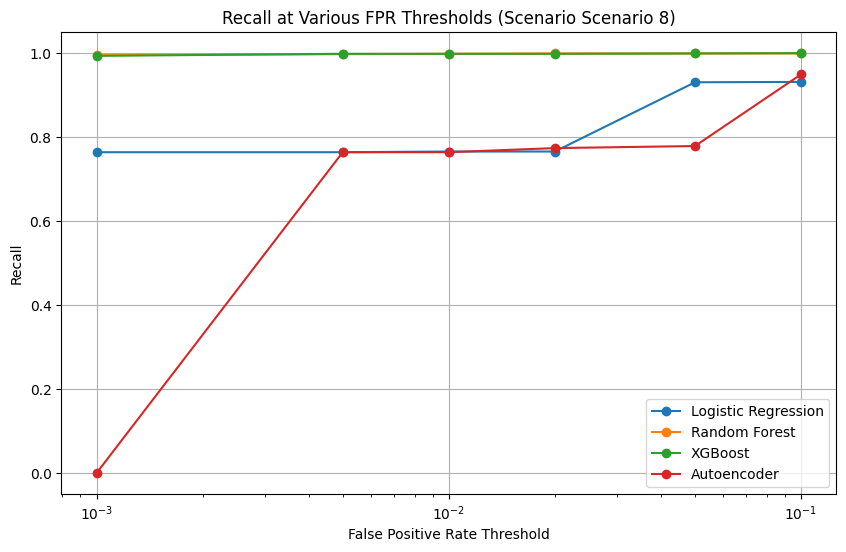

--- Scenario 11 Performance at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic Recall: 0.00% | RF Recall: 2.74% | XGB Recall: 5.21% | AE Recall: 99.74%
FPR Threshold: 0.500% | Logistic Recall: 0.00% | RF Recall: 8.84% | XGB Recall: 6.16% | AE Recall: 99.74%
FPR Threshold: 1.000% | Logistic Recall: 0.00% | RF Recall: 99.90% | XGB Recall: 8.84% | AE Recall: 99.74%
FPR Threshold: 2.000% | Logistic Recall: 0.04% | RF Recall: 99.90% | XGB Recall: 99.90% | AE Recall: 99.74%
FPR Threshold: 5.000% | Logistic Recall: 0.04% | RF Recall: 99.90% | XGB Recall: 99.98% | AE Recall: 99.74%
FPR Threshold: 10.000% | Logistic Recall: 0.07% | RF Recall: 99.90% | XGB Recall: 100.00% | AE Recall: 99.74%


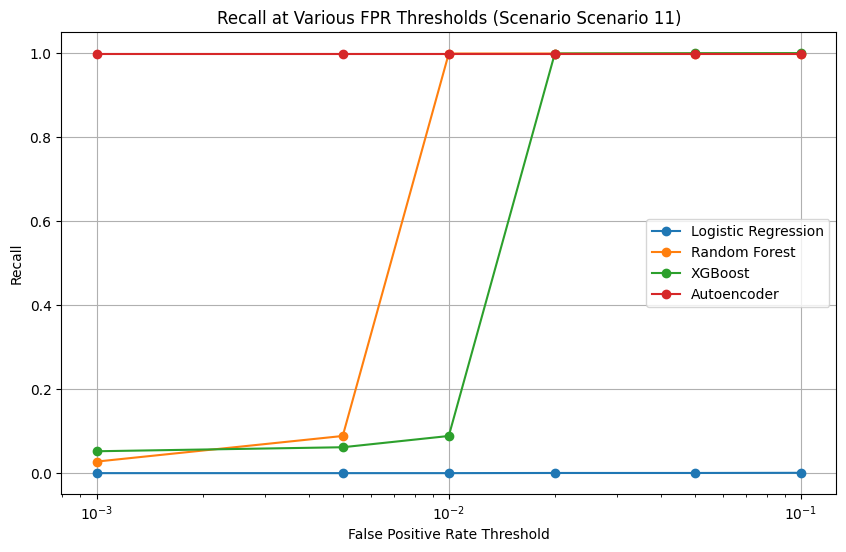

--- Scenario 1 Performance at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic Recall: 6.51% | RF Recall: 23.14% | XGB Recall: 22.84% | AE Recall: 0.00%
FPR Threshold: 0.500% | Logistic Recall: 7.20% | RF Recall: 23.97% | XGB Recall: 24.34% | AE Recall: 0.11%
FPR Threshold: 1.000% | Logistic Recall: 7.24% | RF Recall: 25.37% | XGB Recall: 25.27% | AE Recall: 0.47%
FPR Threshold: 2.000% | Logistic Recall: 7.50% | RF Recall: 26.83% | XGB Recall: 26.58% | AE Recall: 7.03%
FPR Threshold: 5.000% | Logistic Recall: 8.39% | RF Recall: 27.63% | XGB Recall: 32.13% | AE Recall: 7.54%
FPR Threshold: 10.000% | Logistic Recall: 9.00% | RF Recall: 28.80% | XGB Recall: 37.42% | AE Recall: 9.39%


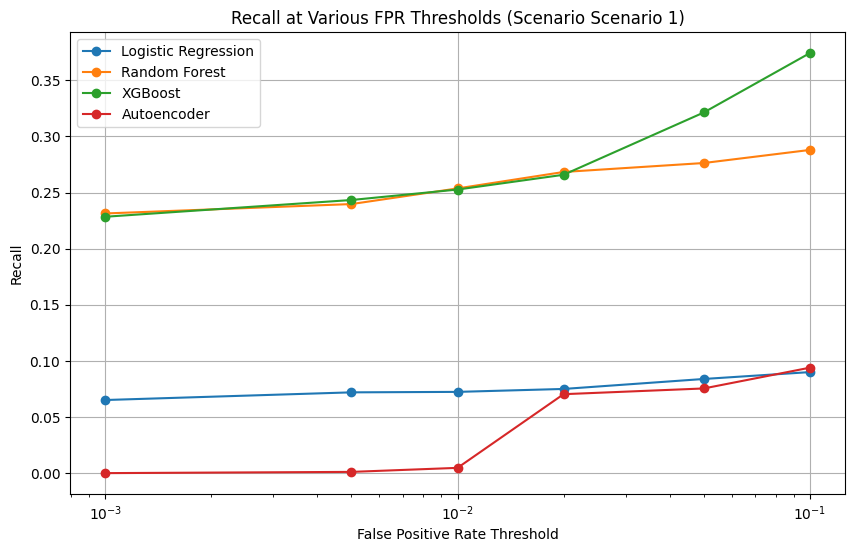

In [60]:
# Test all of the models over various FPR thresholds to see how they perform across the board
thresholds = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]

#test on scenario 8
evaluate_all_models_on_scenario(X_test_scaled, X_test, y_test, "Scenario 8", thresholds)
#test on scenario 11
evaluate_all_models_on_scenario(X_11_scaled, X_11, y_11, "Scenario 11", thresholds)
#test on scenario 1
evaluate_all_models_on_scenario(X_1_scaled, X_1, y_1, "Scenario 1", thresholds)